<a href="https://colab.research.google.com/github/io-uty/skt-bigdata-analysis/blob/main/08_ML_K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-평균 군집화 (k-Means Clustering)
- K-Means Clustering
  - 정답(label)이 없는 데이터들을 특성에 따라 유사한 k개의 그룹(cluster)로 묶어주는 대표적 비지도학습 (unsupervised Learning) 알고리즘

- ML Unsupervised Learning 에 속한다.
- 데이터를 K개의 Cluster로 묶는 알고리즘이다.
- 각 군집의 평균을 활용하여 K개의 군집으로 묶는다는 의미이다.
- 여기서 평균이란 각 클러스터의 중심과 데이터들의 평균 거리를 의미한다.

> 알고리즘 설명
- k-평균 군집화 알고리즘은 5단계로 실행된다.

1. K개의 임의의 중심점 배치 (centroids)
2. 각 데이터들의 가장 가까운 중심점으로 할당해서 군집 형성
3. 각 군집으로 지정된 데이터들을 기반으로 해당 군집의 중심점의 위치 업데이트
4. 더이상 중심점의 위치가 움직이지 않을 때까지 2번, 3번 단계를 반복한다.

- Kaggle이 Mall Customers Clustering Analysis데이터를 활용하여 군집화를 실행

In [1]:
import numpy as np
import pandas as pd

customers = pd.read_csv("https://raw.githubusercontent.com/arienugroho050396/Mall-Customer-Segmentation-Unsupervised-ML/refs/heads/main/Mall_Customers.csv")
customers.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
df = customers[[
    'Annual Income (k$)', 'Spending Score (1-100)'
]]
df.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


- 스케일링: 데이터 사이의 거리를 사용하는 알고리즘이기 때문:

In [9]:
from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler()
df = sc.fit_transform(df)
df[:10]

array([[0.        , 0.3877551 ],
       [0.        , 0.81632653],
       [0.00819672, 0.05102041],
       [0.00819672, 0.7755102 ],
       [0.01639344, 0.39795918],
       [0.01639344, 0.76530612],
       [0.02459016, 0.05102041],
       [0.02459016, 0.94897959],
       [0.03278689, 0.02040816],
       [0.03278689, 0.7244898 ]])

- 알고리즘 학습

In [16]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3)
model.fit(df)

KMeans(n_clusters=3)

In [18]:
df = pd.DataFrame(df, columns=['Annual Income (k$)', 'Spending Score (1-100)'])
#array를 dataframe으로 바꾸어야함

- 1. 스케일링 수행 (NumPy 배열 반환) scaled_array=sc.fit_transform(df)
- 2. 원래 컬럼명을 사용하여 DataFrame으로 재구성

In [20]:
pred = model.predict(df)
df['label'] = pred
pred[:30]

array([1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2], dtype=int32)

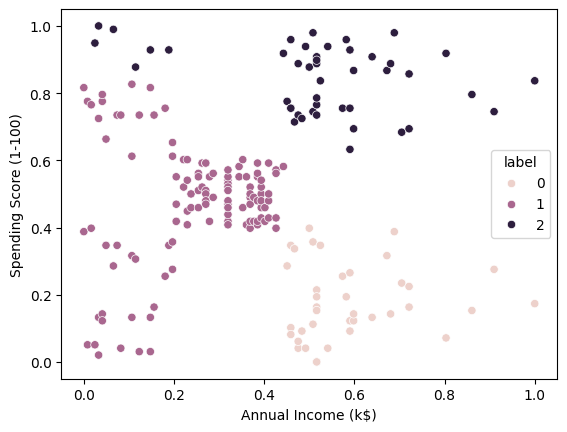

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(data=df, x = 'Annual Income (k$)', y='Spending Score (1-100)', hue = 'label')

plt.show()

> 엘보우 메소드 (Elbow Method)
- k값 변경하면서 각 군집의 응집도 저장

In [31]:
inertia = []
for i in range(1,10):
  model = KMeans(n_clusters=i, init='random', random_state=42)
  model.fit(df)
  inertia.append(model.inertia_)

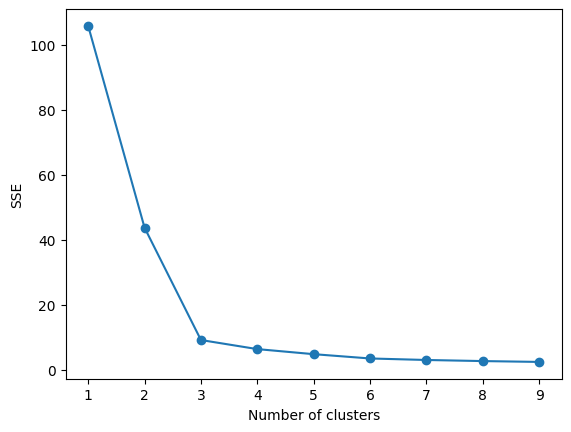

In [36]:
plt.subplots()
plt.plot(range(1,10), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.show()

### K-Means 알고리즘을 활용하여 쇼핑몰 고객을 군집화

In [37]:
from sklearn.preprocessing import StandardScaler

df = pd.DataFrame({
    'CustomerID': range(1, 11),
    'Genre': ['Male', 'Female', 'Female', 'Female', 'Male', 'Female', 'Female', 'Female', 'Male', 'Female'],
    'Age': [19, 21, 20, 23, 31, 22, 35, 23, 64, 30],
    'Annual Income (k$)': [15, 15, 16, 16, 17, 17, 18, 18, 19, 19],
    'Spending Score (1-100)': [39, 81, 6, 77, 40, 76, 6, 94, 3, 72]
})

- 데이터 전처리 및 특성 선택

In [38]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

- 최적의 군집 수 찾기 (Elbow Method)

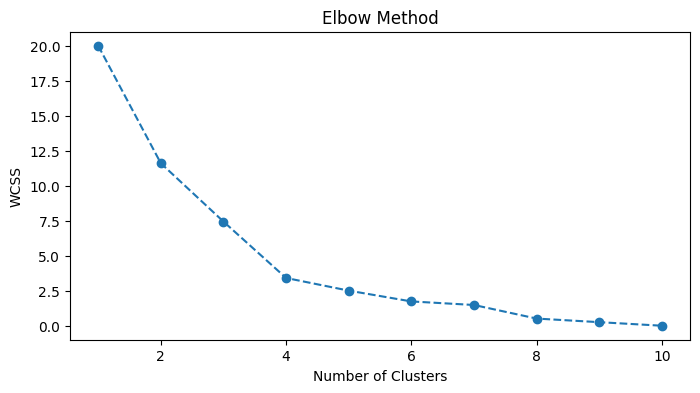

In [39]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# 엘보우 그래프 시각화
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


- K-Means 모델 학습 및 예측

In [40]:
# 최적의 군집 수(K=5)로 모델 생성 및 학습
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_transform(X_scaled).argmin(axis=1) # 각 데이터의 군집 할당

# 군집 결과 확인
print(df.head())


   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2  Female   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5    Male   31                  17                      40   

   Cluster  
0        4  
1        0  
2        2  
3        0  
4        2  


- 군집 결과 시각화

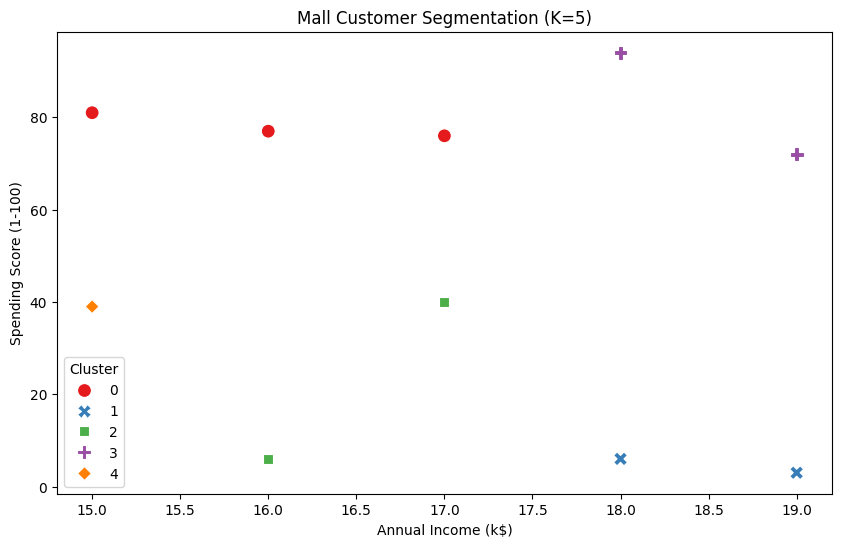

In [41]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100,
    style='Cluster'
)
plt.title('Mall Customer Segmentation (K=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()


- **대표적인 5개 고객 군집 해석**

  - Cluster 0: 소득은 낮지만 지출 점수가 높은 고객 (잠재적 충성 고객)
  - Cluster 1: 소득도 높고 지출 점수도 높은 고객 (핵심 타겟 타겟)
  - Cluster 2: 소득은 낮고 지출 점수도 낮은 고객 (절약형 고객)
  - Cluster 3: 소득은 높지만 지출 점수가 낮은 고객 (신중한 자산가)
  - Cluster 4: 소득과 지출 모두 평균 수준인 고객 (일반 대중)